In [117]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [56]:
num = [1,2,2,3,3,3,4,4,4,4]

for i in num:
    count = num.count(i)
    print(i,"--",count)

1 -- 1
2 -- 2
2 -- 2
3 -- 3
3 -- 3
3 -- 3
4 -- 4
4 -- 4
4 -- 4
4 -- 4


In [57]:
data = {
"Aman": [85, 90, 78],
"Eakam": [92, 88, 95],
"Kiran": [70, 75, 80]
}

for name, marks in data.items():
    avg = sum(marks)/len(marks)
    print(name, ":", avg)

Aman : 84.33333333333333
Eakam : 91.66666666666667
Kiran : 75.0


In [58]:
df = pd.read_csv("health_care.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [59]:
print("Shape:", df.shape)

Shape: (768, 9)


In [60]:
print("Shape:", df.shape)

Shape: (768, 9)


In [61]:
print(df.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [62]:
df.describe().mean()

Pregnancies                 100.276829
Glucose                     184.514644
BloodPressure               149.057659
SkinThickness               119.811084
Insulin                     245.849185
BMI                         121.359592
DiabetesPedigreeFunction     96.567963
Age                         126.125140
Outcome                      96.353239
dtype: float64

In [63]:
df.median()

Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                23.0000
Insulin                      30.5000
BMI                          32.0000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64

In [64]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [65]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [66]:
df.drop_duplicates(inplace=True)

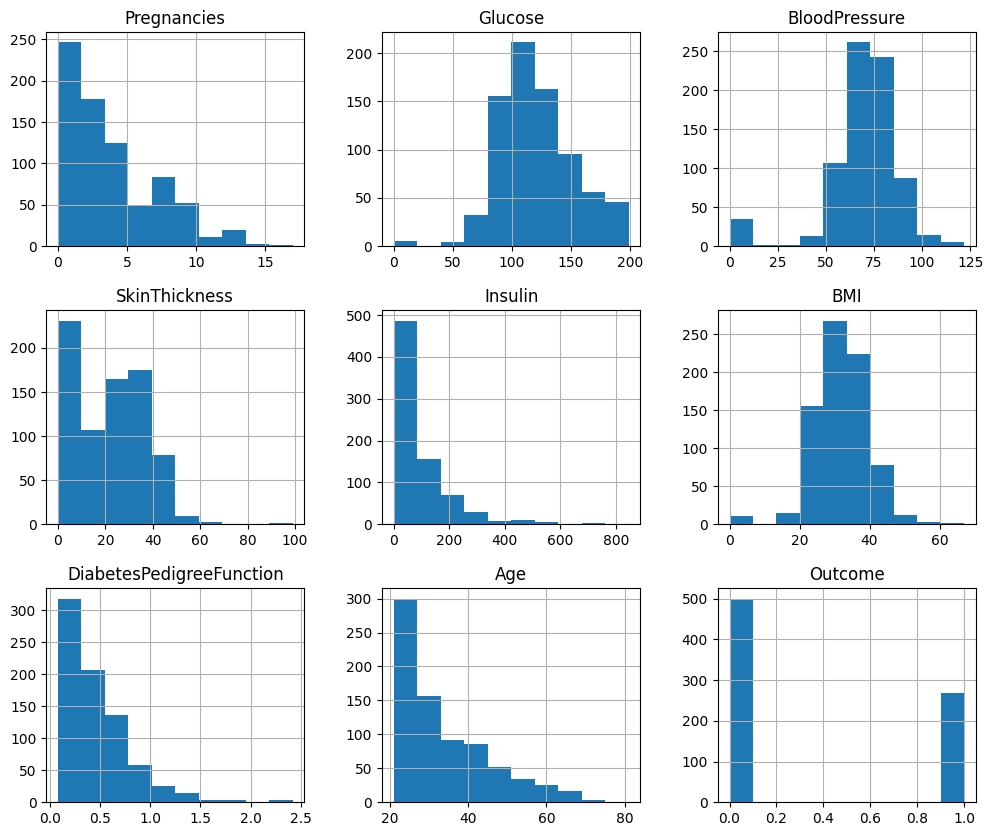

In [67]:
df.hist(figsize=(12,10))
plt.show()


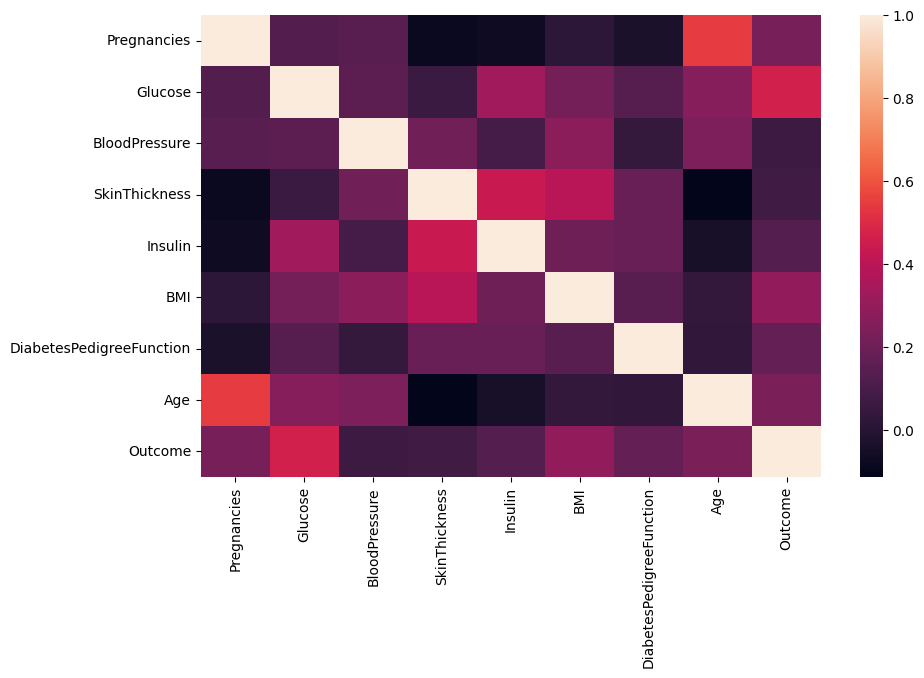

In [68]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr())
plt.show()

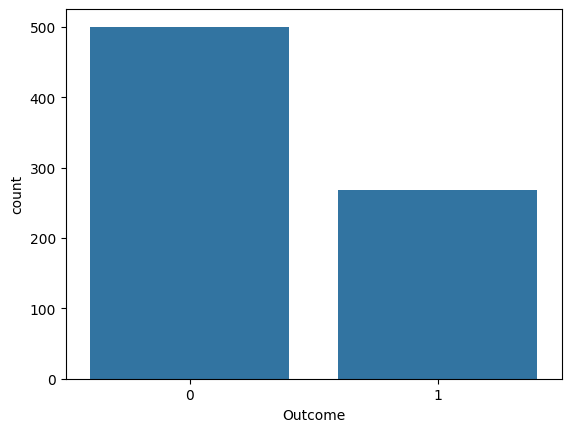

In [69]:
sns.countplot(x='Outcome', data=df)
plt.show()

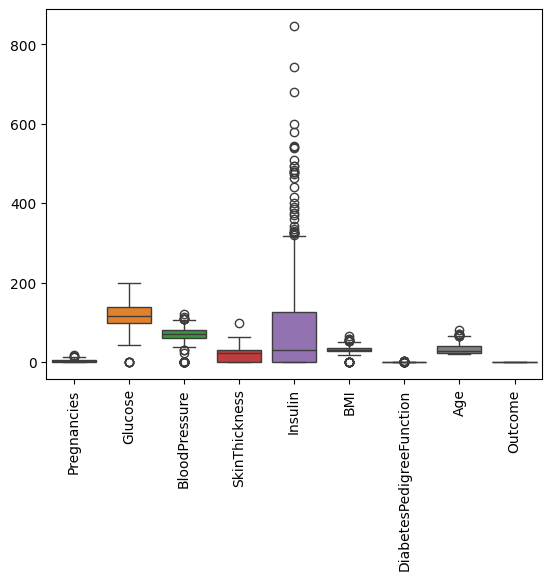

In [70]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

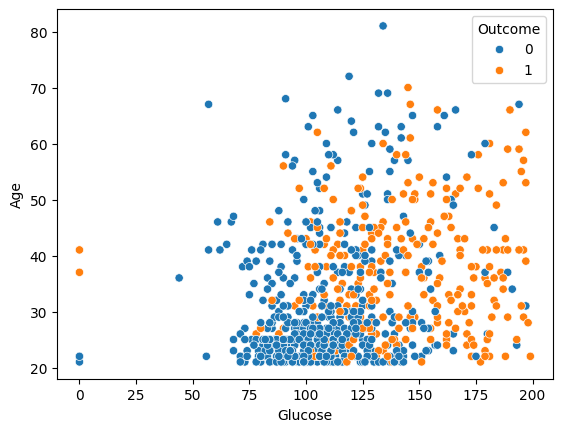

In [71]:
sns.scatterplot(x='Glucose', y='Age', hue='Outcome', data=df)
plt.show()

In [72]:
df1 = pd.read_csv("ml.csv")

In [73]:
df1.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [74]:
experience= df1["time_spend_company"] / df1["number_project"]

In [75]:
df1.insert(9,'experience',experience)

In [76]:
df1.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,experience,salary
0,0.38,0.53,2,157,3,0,1,0,sales,1.500000,low
1,0.80,0.86,5,262,6,0,1,0,sales,1.200000,medium
2,0.11,0.88,7,272,4,0,1,0,sales,0.571429,medium
3,0.72,0.87,5,223,5,0,1,0,sales,1.000000,low
4,0.37,0.52,2,159,3,0,1,0,sales,1.500000,low


In [78]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   experience             14999 non-null  float64
 10  salary                 14999 non-null  object 
dtypes: float64(3), int64(6), object(2)
memory usage: 1.3+ MB


In [83]:
df1.Work_accident.value_counts()

Work_accident
0    12830
1     2169
Name: count, dtype: int64

In [86]:
df1.drop("Work_accident",axis= 1,inplace=True)

In [87]:
enc = LabelEncoder()

In [103]:
df1["Department"] = enc.fit_transform(df1["Department"])
df1["salary"] = enc.fit_transform(df1["salary"])

In [104]:
df1.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,left,promotion_last_5years,Department,experience,salary
0,0.38,0.53,2,157,3,1,0,7,1.500000,1
1,0.80,0.86,5,262,6,1,0,7,1.200000,2
2,0.11,0.88,7,272,4,1,0,7,0.571429,2
3,0.72,0.87,5,223,5,1,0,7,1.000000,1
4,0.37,0.52,2,159,3,1,0,7,1.500000,1


In [105]:
df1.Department.value_counts()

Department
7    4140
9    2720
8    2229
0    1227
6     902
5     858
1     787
2     767
3     739
4     630
Name: count, dtype: int64

In [106]:
x= df1.iloc[:,:-1]

In [107]:
x

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,left,promotion_last_5years,Department,experience
0,0.38,0.53,2,157,3,1,0,7,1.500000
1,0.80,0.86,5,262,6,1,0,7,1.200000
2,0.11,0.88,7,272,4,1,0,7,0.571429
3,0.72,0.87,5,223,5,1,0,7,1.000000
4,0.37,0.52,2,159,3,1,0,7,1.500000
...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,1,0,8,1.500000
14995,0.37,0.48,2,160,3,1,0,8,1.500000
14996,0.37,0.53,2,143,3,1,0,8,1.500000
14997,0.11,0.96,6,280,4,1,0,8,0.666667


In [108]:
y = df1.iloc[:,-1]

In [109]:
y

0        1
1        2
2        2
3        1
4        1
        ..
14994    1
14995    1
14996    1
14997    1
14998    1
Name: salary, Length: 14999, dtype: int64

In [110]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=32)

In [113]:
lr = LogisticRegression()
rf = RandomForestClassifier()

In [115]:
#logistic regression

lr.fit(x_train,y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [116]:
y_pred_lr = lr.predict(x_test)

In [ ]:
print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.4836666666666667
[[  0 133 128]
 [  0 985 476]
 [  0 812 466]]


In [123]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [128]:
print("Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
Accuracy: 0.6126666666666667
[[  74  107   80]
 [   7 1003  451]
 [  13  504  761]]
